In [1]:
import pennylane as qp
from pennylane import numpy as qnp
from IQP_circuit_pennylane import *
from MaxCut import *
from Partition import *
import jax
import json
import jax.numpy as jnp
import matplotlib.pyplot as plt

In [2]:
def ising_obs(n_qubits: int, corr: int = 2) -> np.ndarray:
    observables = []
    for i in range(n_qubits):
        observable = [0] * n_qubits
        observable[i] = 1
        observables.append(observable)
    if corr == 2:
        for i in range(n_qubits):
            for j in range(i + 1, n_qubits):
                observable = [0] * n_qubits
                observable[i] = 1
                observable[j] = 1
                observables.append(observable)
    return np.array(observables, dtype=int)

In [3]:
import IQP_circuit_pennylane
IQP_circuit_pennylane.ising_obs = ising_obs

In [4]:
with open("ising.json", "r") as f:
    dataset_ising = json.load(f)

# Convert keys back to integers
dataset_ising = {int(k): v for k, v in dataset_ising.items()}

with open("maxcut.json", "r") as f:
    dataset_maxcut = json.load(f)

# Convert keys back to integers
dataset_maxcut = {int(k): v for k, v in dataset_maxcut.items()}

with open("partition.json", "r") as f:
    dataset_partition = json.load(f)

# Convert keys back to integers
dataset_partition = {int(k): v for k, v in dataset_partition.items()}

print("Dataset loaded successfully")

dataset = {
    'ising': dataset_ising,
    'maxcut': dataset_maxcut,
    'partition': dataset_partition
}

Dataset loaded successfully


In [3]:
# mode_ham = 'partition'
# mode_circuit = 'full'
# n_qubits = 3
# ops, coeffs = hamiltonian_data(dataset[mode_ham][n_qubits][1], n_qubits, mode_ham)
# single_params, pair_params = prepare_params(mode_circuit, n_qubits, qnp.pi, 0.005)
# H = binary_ops_to_hamiltonian(ops, coeffs)
# # qp.draw_mpl(iqp_circuit)(single_params, pair_params, H, mode_circuit)
# opt = qp.AdamOptimizer(0.05)

# steps = 1001

# for step in range(steps):

#     (single_params, pair_params, _), loss = opt.step_and_cost(
#         cost,
#         single_params,
#         pair_params,
#         H,
#         mode_circuit = 'full'
#     )

#     if step % 100 == 0:
#         print(
#             f"Step {step:3d} "
#             f"Loss={loss:.6f} "
#             # f"Observable={-loss:.6f}"
#         )

In [4]:
# labels = [np.binary_repr(i, n_qubits) for i in range(2**n_qubits)]
# probs = state_probs(single_params, pair_params, mode_circuit = 'full')
# # Plotting the histogram using matplotlib
# plt.figure(figsize=(8, 5))
# plt.bar(labels, probs, edgecolor='black', alpha=0.8)

# plt.xlabel('Basis State', fontsize=12)
# plt.ylabel('Probability', fontsize=12)
# plt.title('Quantum Circuit Measurement Probabilities', fontsize=14)
# plt.xticks(rotation=90)
# plt.grid(axis='y', linestyle='--', alpha=0.7)
# plt.tight_layout()
# plt.show()

In [5]:
# mode_ham = 'partition'
# mode_circuit = 'full'
# n_qubits = 15
# ops, coeffs = hamiltonian_data(dataset[mode_ham][n_qubits][1], n_qubits, mode_ham)
# single_params, pair_params = prepare_params(mode_circuit, n_qubits, 0, 1e-12)
# H = binary_ops_to_hamiltonian(ops, coeffs)

In [6]:
# grad_fn = qp.grad(cost)
# grad = grad_fn(single_params, pair_params, H, mode_circuit = 'full')
# grad

In [5]:
def gradient_variance(
    cost,
    H,
    mode_circuit,
    theta,
    epsilon,
    n_trials = 1000,
    print_screen = True
):

    grad_fn = qp.grad(cost)
    all_grads = []
    
    for k in range(n_trials):

        single_params, pair_params = prepare_params(mode_circuit, n_qubits, theta, epsilon)
        grad = grad_fn(single_params, pair_params, H, mode_circuit)

        all_grads.append(np.concatenate([grad[0], grad[1]], axis=0))
        if print_screen:
            print(k, 'Done')

    all_grads = np.array(all_grads)

    # variance for each parameter
    var_per_param = np.var(all_grads, axis=0)

    # average variance
    avg_var = np.mean(var_per_param)

    return avg_var

In [8]:
# import time

In [9]:
# mode_hamiltonians = ['ising', 'maxcut', 'partition']
# mode_circuits = ['single', 'circular', 'full']
# epsilons = [1e-0, 1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6, 1e-7, 1e-8, 1e-9, 1e-10, 1e-1, 1e-12]
# theta = np.pi/4

In [10]:
# mode_hamiltonians = ['ising', 'maxcut', 'partition']
# mode_circuits = ['single', 'circular', 'full']
# epsilons = [1e-0, 1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6, 1e-7, 1e-8, 1e-9, 1e-10, 1e-1, 1e-12]
# theta = np.pi/4

# mode_ham = 'ising'
# mode_circuit = 'single'
# n_qubits = 9
# ops, coeffs = hamiltonian_data(dataset[mode_ham][n_qubits][1], n_qubits, mode_ham)
# H = binary_ops_to_hamiltonian(ops, coeffs)
# var_plot = []
# for epsilon in epsilons:
#     var_plot.append(gradient_variance(cost, H, mode_circuit, theta, epsilon, 100, False)[0])

In [11]:
# plt.plot(epsilons, var_plot, "-o")
# plt.xscale('log')
# plt.yscale('log')

### Chương Version

In [ ]:
import numpy as np

# ============================================================
# Experiment settings
# ============================================================

mode_hamiltonians = ['ising', 'maxcut', 'partition']
mode_circuits = ['single', 'circular', 'full']

qubits = [3, 6, 9, 12, 15, 18]

epsilons = [1e-1, 1e-3, 1e-5, 1e-7, 1e-9, 1e-11]

theta = np.pi / 4

n_problem = 10      # number of Hamiltonian instances
n_trials = 100      # Monte Carlo trials for gradient variance

# ============================================================
# Storage
# ============================================================

gradient_variance_results = {}

# ============================================================
# Main loop
# ============================================================

for mode_ham in mode_hamiltonians:

    print(f"\nHamiltonian: {mode_ham}")

    gradient_variance_results[mode_ham] = {}

    for mode_circuit in mode_circuits:

        print(f"  Circuit: {mode_circuit}")

        gradient_variance_results[mode_ham][mode_circuit] = {}

        for n_qubits in qubits:

            print(f"    Qubits = {n_qubits}")

            gradient_variance_results[mode_ham][mode_circuit][n_qubits] = {}

            for problem_id in range(n_problem):

                print(f"      Problem {problem_id+1}/{n_problem}", end="\r")

                # Build Hamiltonian
                ops, coeffs = hamiltonian_data(
                    dataset[mode_ham][n_qubits][problem_id],
                    n_qubits,
                    mode_ham
                )

                H = binary_ops_to_hamiltonian(ops, coeffs)

                gradient_variance_results[mode_ham][mode_circuit][n_qubits][problem_id] = {}

                for epsilon in epsilons:

                    variance = gradient_variance(
                        cost,
                        H,
                        mode_circuit,
                        theta,
                        epsilon,
                        n_trials,
                        False
                    )

                    gradient_variance_results[mode_ham][mode_circuit][n_qubits][problem_id][epsilon] = variance

            print()


Hamiltonian: ising
  Circuit: single
    Qubits = 3
      Problem 10/10
    Qubits = 6
      Problem 10/10
    Qubits = 9
      Problem 10/10
    Qubits = 12
      Problem 10/10
    Qubits = 15
      Problem 10/10
    Qubits = 18
      Problem 10/10
  Circuit: circular
    Qubits = 3
      Problem 10/10
    Qubits = 6
      Problem 10/10
    Qubits = 9
      Problem 10/10
    Qubits = 12
      Problem 10/10
    Qubits = 15
      Problem 10/10
    Qubits = 18
      Problem 10/10
  Circuit: full
    Qubits = 3
      Problem 10/10
    Qubits = 6
      Problem 10/10
    Qubits = 9
      Problem 10/10
    Qubits = 12
      Problem 10/10
    Qubits = 15
      Problem 10/10
    Qubits = 18
      Problem 10/10

Hamiltonian: maxcut
  Circuit: single
    Qubits = 3
      Problem 10/10
    Qubits = 6
      Problem 10/10
    Qubits = 9
      Problem 10/10
    Qubits = 12
      Problem 10/10
    Qubits = 15
      Problem 10/10
    Qubits = 18
      Problem 10/10
  Circuit: circular
    Qubits = 3


In [ ]:
import json

with open("gv_pi4.json", "w") as f:
    json.dump(gradient_variance_results, f, indent=4)

print("Dataset saved to gv_pi4.json")

Dataset saved to gv_pi4.json


## Claude Version

In [6]:
mode_hamiltonians = ['ising', 'maxcut', 'partition']
mode_circuits     = ['single', 'circular', 'full']
qubits            = [3, 6, 9, 12, 15, 18]
n_problem         = 10
n_trials          = 100
theta             = np.pi / 4
epsilon           = 0.05   # fixed, giống paper gốc

results = {}

for mode_ham in mode_hamiltonians:
    print(f"\n=== {mode_ham} ===")
    results[mode_ham] = {}

    for mode_circuit in mode_circuits:
        print(f"  {mode_circuit}")
        results[mode_ham][mode_circuit] = {}

        for n_qubits in qubits:
            print(f"    n={n_qubits}", end=" ... ", flush=True)
            grad_vars = []

            for problem_id in range(n_problem):
                ops, coeffs = hamiltonian_data(
                    dataset[mode_ham][n_qubits][problem_id],
                    n_qubits, mode_ham
                )
                H = binary_ops_to_hamiltonian(ops, coeffs)

                variance = gradient_variance(
                    cost, H, mode_circuit,
                    theta=theta, epsilon=epsilon,
                    n_trials=n_trials, print_screen=False
                )
                grad_vars.append(variance)

            results[mode_ham][mode_circuit][n_qubits] = grad_vars
            print(f"mean={np.mean(grad_vars):.2e}")

with open("gv_exact_normal.json", "w") as f:
    json.dump(results, f, indent=4)
print("Saved.")


=== ising ===
  single
    n=3 ... mean=6.56e-04
    n=6 ... mean=2.62e-03
    n=9 ... mean=5.79e-03
    n=12 ... mean=8.53e-03
    n=15 ... mean=1.37e-02
    n=18 ... mean=1.86e-02
  circular
    n=3 ... mean=1.19e-03
    n=6 ... mean=1.72e-03
    n=9 ... mean=3.17e-03
    n=12 ... mean=4.25e-03
    n=15 ... mean=6.50e-03
    n=18 ... mean=8.34e-03
  full
    n=3 ... mean=1.18e-03
    n=6 ... mean=3.84e-03
    n=9 ... mean=1.09e-02
    n=12 ... mean=1.89e-02
    n=15 ... mean=3.36e-02
    n=18 ... mean=4.93e-02

=== maxcut ===
  single
    n=3 ... mean=8.96e-03
    n=6 ... mean=2.08e-02
    n=9 ... mean=2.37e-02
    n=12 ... mean=2.21e-02
    n=15 ... mean=2.52e-02
    n=18 ... mean=2.33e-02
  circular
    n=3 ... mean=1.76e-02
    n=6 ... mean=1.12e-02
    n=9 ... mean=1.09e-02
    n=12 ... mean=1.00e-02
    n=15 ... mean=9.67e-03
    n=18 ... mean=9.00e-03
  full
    n=3 ... mean=1.79e-02
    n=6 ... mean=3.82e-02
    n=9 ... mean=5.33e-02
    n=12 ... mean=5.22e-02
    n=15 ... me

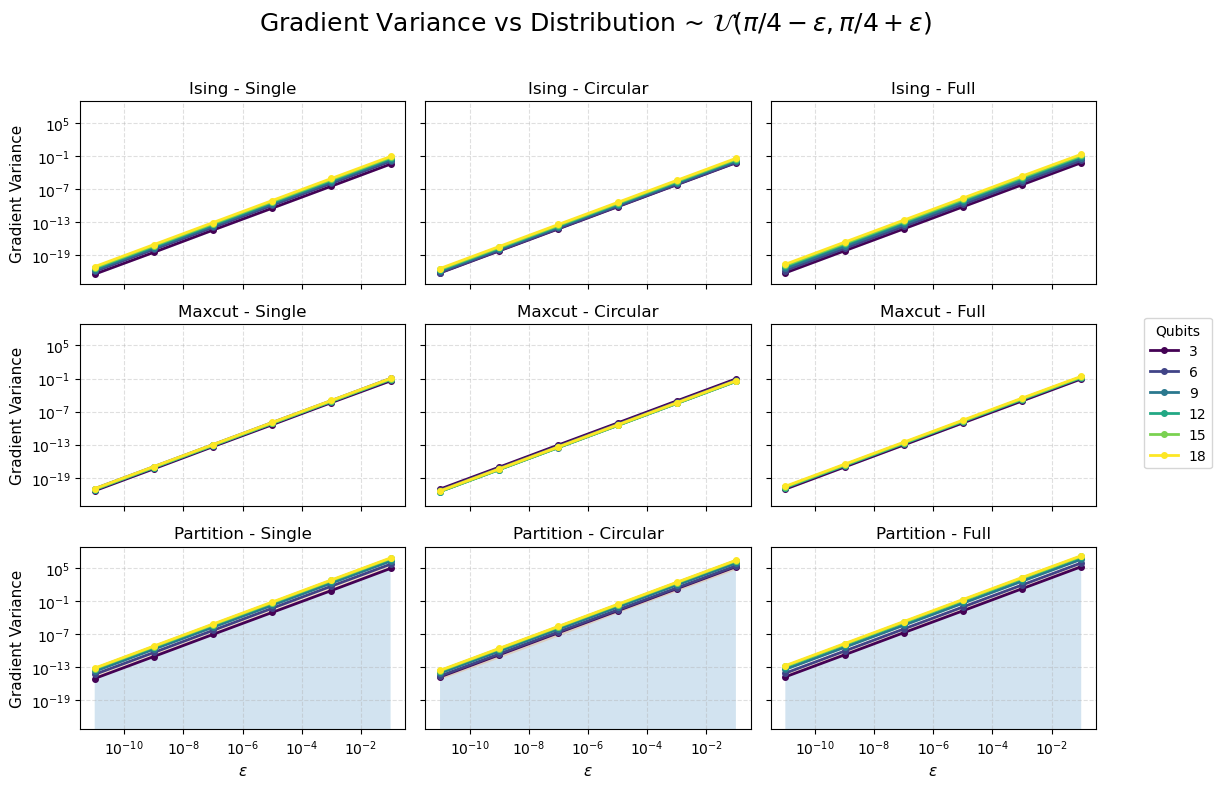

In [33]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    3, 3,
    figsize=(12, 8),
    sharex=True,
    sharey=True
)

eps_array = np.array(epsilons)

# colors = plt.cm.viridis(np.linspace(0, 1, len(qubits)))
colors = plt.colormaps['viridis'](np.linspace(0, 1, len(qubits)))

for i, mode_ham in enumerate(mode_hamiltonians):

    for j, mode_circuit in enumerate(mode_circuits):

        ax = axes[i, j]

        for k, n_qubits in enumerate(qubits):

            means = []
            stds = []

            for eps in epsilons:

                values = [
                    gradient_variance_results[mode_ham][mode_circuit][n_qubits][problem][eps]
                    for problem in range(n_problem)
                ]

                means.append(np.mean(values))
                stds.append(np.std(values))

            means = np.array(means)
            stds = np.array(stds)

            ax.plot(
                eps_array,
                means,
                marker='o',
                linewidth=2,
                markersize=4,
                color=colors[k],
                label=f'{n_qubits}'
            )
            
            ax.fill_between(
                eps_array,
                means - stds,
                means + stds,
                alpha=0.2
            )

        ax.set_xscale('log')
        ax.set_yscale('log')

        ax.grid(True, which='both', linestyle='--', alpha=0.4)

        ax.set_title(
            f'{mode_ham.capitalize()} - {mode_circuit.capitalize()}',
            fontsize=12
        )

        # Only left column gets y-label
        if j == 0:
            ax.set_ylabel("Gradient Variance", fontsize=11)

        # Only bottom row gets x-label
        if i == len(mode_hamiltonians) - 1:
            ax.set_xlabel(r'$\epsilon$', fontsize=11)

# -------------------------------------------------------
# One common legend for the whole figure
# -------------------------------------------------------
handles, labels = axes[0, 0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="Qubits",
    loc="center right",
    bbox_to_anchor=(1.02, 0.5)
)

fig.suptitle(
    "Gradient Variance vs Distribution ~ $\mathcal{U} (\pi/4 - \epsilon, \pi/4 + \epsilon$)",
    fontsize=18,
    y=0.98
)

# fig.legend(
#     handles,
#     labels,
#     title="Qubits",
#     loc="lower center",
#     ncol=len(qubits),
#     bbox_to_anchor=(0.5, -0.02)
# )

# plt.tight_layout(rect=[0, 0.05, 1, 0.96])

plt.tight_layout(rect=[0, 0, 0.93, 0.96])
plt.show()

## Full Computation with 3 distribution


In [5]:
def prepare_params_normal(mode_circuit, n_qubits):
    if mode_circuit == 'single':
        n_pairs = 0
    elif mode_circuit == 'circular':
        n_pairs = n_qubits
    else:
        n_pairs = n_qubits * (n_qubits - 1) // 2

    single_params = qnp.random.normal(0, 1, n_qubits, requires_grad=True)
    pair_params   = qnp.random.normal(0, 1, n_pairs,  requires_grad=True)
    return single_params, pair_params

def prepare_params_uniform(mode_circuit, n_qubits):
    if mode_circuit == 'single':
        n_pairs = 0
    elif mode_circuit == 'circular':
        n_pairs = n_qubits
    else:
        n_pairs = n_qubits * (n_qubits - 1) // 2

    single_params = qnp.random.uniform(-np.pi, np.pi, n_qubits, requires_grad=True)
    pair_params   = qnp.random.uniform(-np.pi, np.pi, n_pairs,  requires_grad=True)
    return single_params, pair_params

In [6]:
def gradient_variance_v2(cost, H, mode_circuit, n_qubits,
                         sampler, n_trials=100, print_screen=False):
    grad_fn = qp.grad(cost)
    all_grads = []

    for k in range(n_trials):
        single_params, pair_params = sampler(mode_circuit, n_qubits)
        grad = grad_fn(single_params, pair_params, H, mode_circuit)
        all_grads.append(np.concatenate([grad[0], grad[1]], axis=0))
        if print_screen:
            print(k, 'Done')

    all_grads = np.array(all_grads)
    return float(np.mean(np.var(all_grads, axis=0)))

In [7]:
samplers = {
    'normal':  prepare_params_normal,
    'pi4':     lambda mode, n: prepare_params(mode, n, np.pi/4, 1e-5),
    'uniform': prepare_params_uniform,
}

mode_hamiltonians = ['ising', 'maxcut', 'partition']
mode_circuits     = ['single', 'circular', 'full']
qubits            = [3, 6, 9, 12, 15, 18]
n_problem         = 10
n_trials          = 100

all_results = {}

for init_name, sampler in samplers.items():
    print(f"\n{'='*40}")
    print(f"Init: {init_name}")
    results = {}

    for mode_ham in mode_hamiltonians:
        print(f"\n  === {mode_ham} ===")
        results[mode_ham] = {}

        for mode_circuit in mode_circuits:
            print(f"    {mode_circuit}")
            results[mode_ham][mode_circuit] = {}

            for n_qubits in qubits:
                print(f"      n={n_qubits}", end=" ... ", flush=True)
                grad_vars = []

                for problem_id in range(n_problem):
                    ops, coeffs = hamiltonian_data(
                        dataset[mode_ham][n_qubits][problem_id],
                        n_qubits, mode_ham
                    )
                    H = binary_ops_to_hamiltonian(ops, coeffs)

                    ops_arr = np.array(ops)
                    off_diag_mask = ops_arr.any(axis=1)          # True nếu không phải Identity (i.e., i != j)
                    norm_sq = float(np.sum(np.array(coeffs)[off_diag_mask] ** 2))

                    variance = gradient_variance_v2(
                        cost, H, mode_circuit, n_qubits,
                        sampler=sampler,
                        n_trials=n_trials, print_screen=False
                    )
                    grad_vars.append(variance / norm_sq)

                results[mode_ham][mode_circuit][n_qubits] = grad_vars
                print(f"mean={np.mean(grad_vars):.2e}")

    all_results[init_name] = results

with open("gv_exact_all_eps1e-5_norm.json", "w") as f:
    json.dump(all_results, f, indent=4)
print("\nSaved to gv_exact_all_eps1e-5_norm.json")


Init: normal

  === ising ===
    single
      n=3 ... mean=3.10e-01
      n=6 ... mean=2.87e-01
      n=9 ... mean=2.73e-01
      n=12 ... mean=2.57e-01
      n=15 ... mean=2.54e-01
      n=18 ... mean=2.53e-01
    circular
      n=3 ... mean=1.31e-01
      n=6 ... mean=6.49e-02
      n=9 ... mean=5.09e-02
      n=12 ... mean=3.96e-02
      n=15 ... mean=3.72e-02
      n=18 ... mean=3.23e-02
    full
      n=3 ... mean=1.30e-01
      n=6 ... mean=9.65e-03
      n=9 ... mean=8.25e-04
      n=12 ... mean=8.88e-05
      n=15 ... mean=1.06e-05
      n=18 ... mean=1.21e-06

  === maxcut ===
    single
      n=3 ... mean=2.46e-01
      n=6 ... mean=1.63e-01
      n=9 ... mean=1.18e-01
      n=12 ... mean=8.75e-02
      n=15 ... mean=7.37e-02
      n=18 ... mean=6.21e-02
    circular
      n=3 ... mean=9.94e-02
      n=6 ... mean=3.29e-02
      n=9 ... mean=1.87e-02
      n=12 ... mean=1.33e-02
      n=15 ... mean=1.05e-02
      n=18 ... mean=8.45e-03
    full
      n=3 ... mean=9.70e-02
  

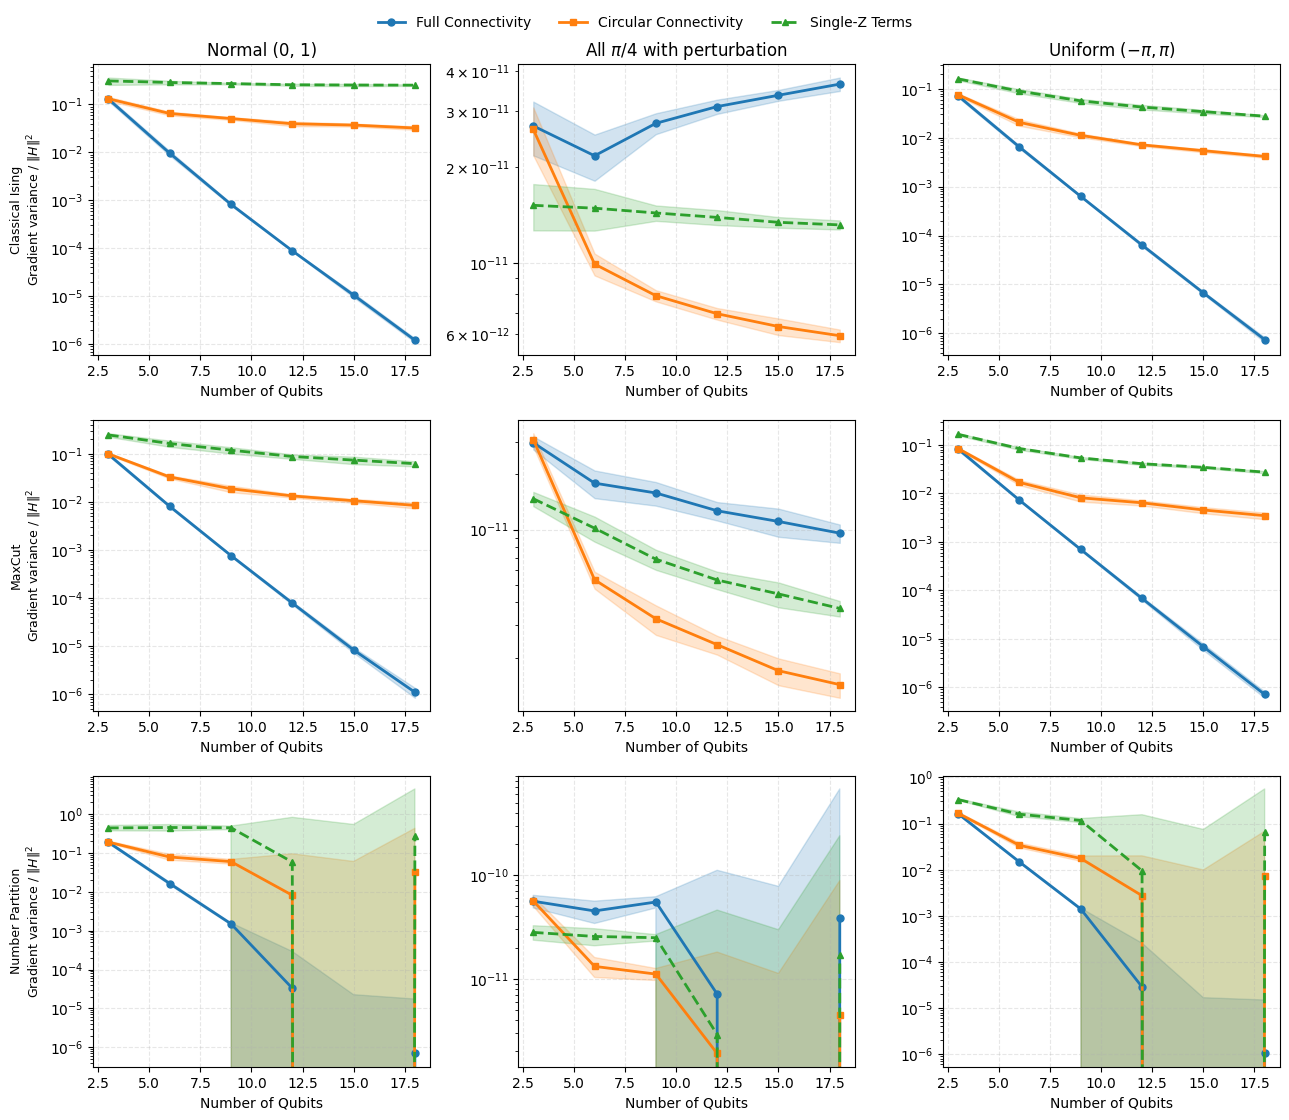

In [8]:
import json
import numpy as np
import matplotlib.pyplot as plt

with open("gv_exact_all_eps1e-5_norm.json", "r") as f:
    all_results = json.load(f)

qubits = [3, 6, 9, 12, 15, 18]

ham_names = {
    'ising':     'Classical Ising',
    'maxcut':    'MaxCut',
    'partition': 'Number Partition'
}
styles = {
    'full':     ('o-', '#1f77b4'),
    'circular': ('s-', '#ff7f0e'),
    'single':   ('^--', '#2ca02c')
}
labels = {
    'full':     'Full Connectivity',
    'circular': 'Circular Connectivity',
    'single':   'Single-Z Terms'
}
init_titles = {
    'normal':  'Normal (0, 1)',
    'pi4':     r'All $\pi/4$ with perturbation',
    'uniform': r'Uniform $(-\pi, \pi)$',
}

fig, axes = plt.subplots(3, 3, figsize=(13, 11))

for row, mode_ham in enumerate(['ising', 'maxcut', 'partition']):
    for col, init_name in enumerate(['normal', 'pi4', 'uniform']):
        ax = axes[row][col]
        res = all_results[init_name][mode_ham]

        for mode_circuit in ['full', 'circular', 'single']:
            means = np.array([np.mean(res[mode_circuit][str(n)]) for n in qubits])
            stds  = np.array([np.std(res[mode_circuit][str(n)])  for n in qubits])
            fmt, color = styles[mode_circuit]
            ax.plot(qubits, means, fmt, color=color,
                    label=labels[mode_circuit], linewidth=2, markersize=5)
            ax.fill_between(qubits, means - stds, means + stds,
                            color=color, alpha=0.2)

        ax.set_yscale('log')
        ax.grid(True, alpha=0.3, linestyle='--')
        ax.set_xlabel('Number of Qubits')

        if col == 0:
            ax.set_ylabel(f'{ham_names[mode_ham]}\n'
                          r'Gradient variance / $\|H\|^2$', fontsize=9)
        if row == 0:
            ax.set_title(init_titles[init_name])

handles, labels_ = axes[0][0].get_legend_handles_labels()
fig.legend(handles, labels_, loc='upper center', ncol=3,
           bbox_to_anchor=(0.5, 1.02), frameon=False)

plt.tight_layout()
plt.savefig("GV_exact_all_epsilon1e-5_norm.pdf", dpi=300, bbox_inches='tight')
plt.show()

## Scale with max variance for each Ham - same distribution

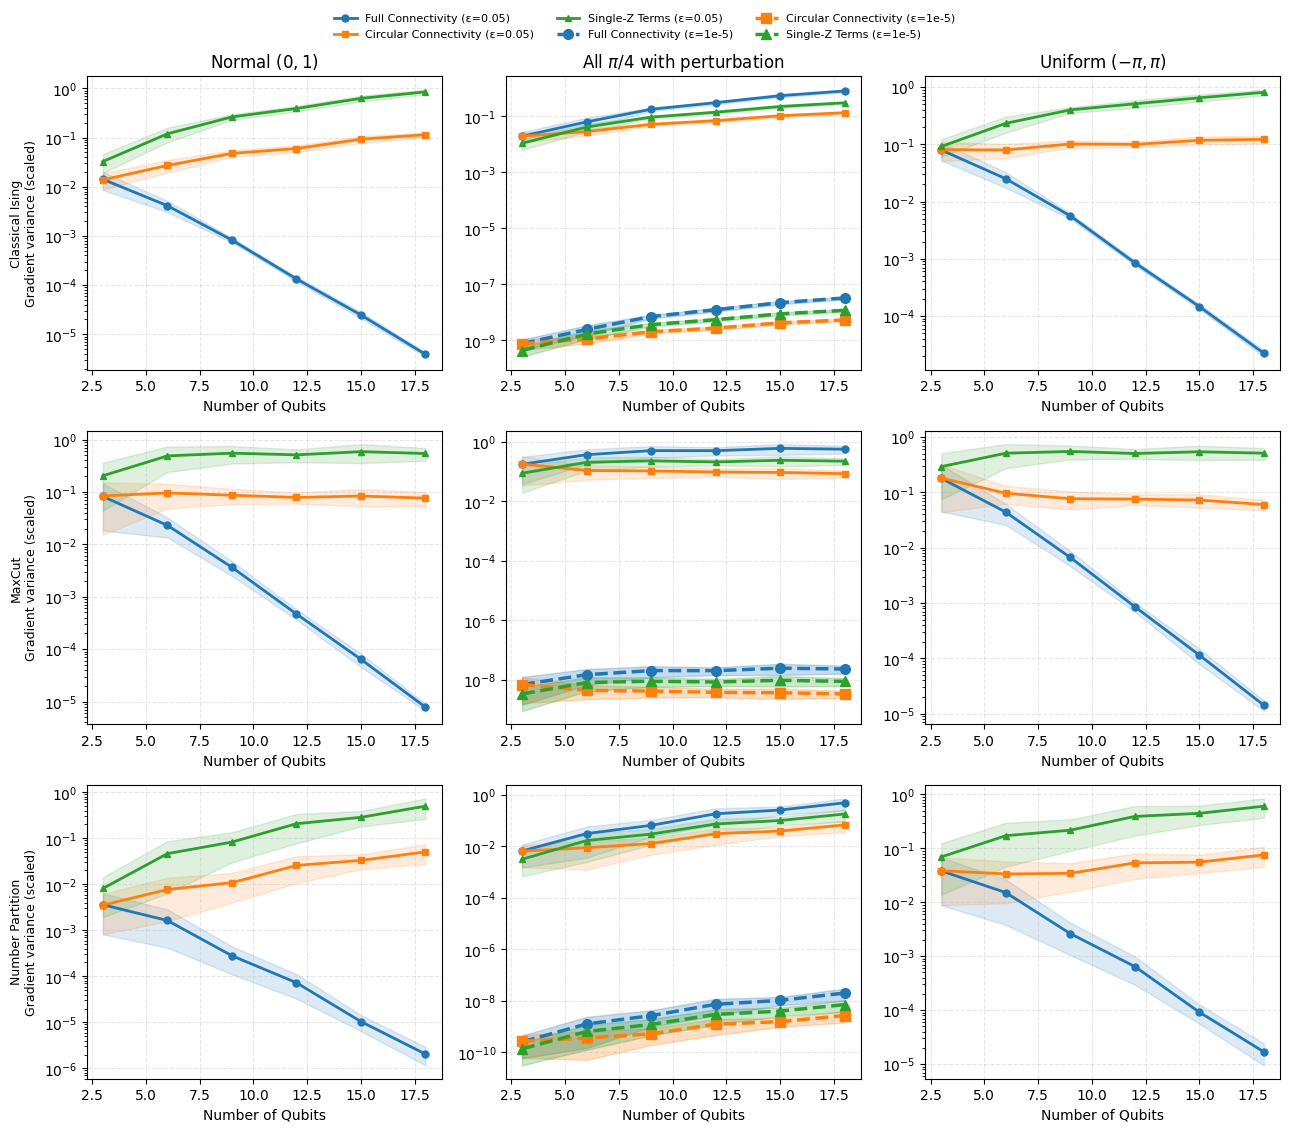

Saved: GV_compare_maxvar.pdf


In [12]:
import json
import numpy as np
import matplotlib.pyplot as plt

with open("gv_exact_all_eps0.05.json", "r") as f:
    results_005 = json.load(f)

with open("gv_exact_all_eps1e-5.json", "r") as f:
    results_1e5 = json.load(f)

qubits = [3, 6, 9, 12, 15, 18]

ham_names = {
    'ising':     'Classical Ising',
    'maxcut':    'MaxCut',
    'partition': 'Number Partition',
}

circuit_colors  = {'full': '#1f77b4', 'circular': '#ff7f0e', 'single': '#2ca02c'}
circuit_markers = {'full': 'o',       'circular': 's',       'single': '^'}
circuit_labels  = {
    'full':     'Full Connectivity',
    'circular': 'Circular Connectivity',
    'single':   'Single-Z Terms',
}

init_cols  = ['normal', 'pi4', 'uniform']
col_titles = {
    'normal':  r'Normal $(0, 1)$',
    'pi4':     r'All $\pi/4$ with perturbation',
    'uniform': r'Uniform $(-\pi, \pi)$',
}

fig, axes = plt.subplots(3, 3, figsize=(13, 11))

for row, mode_ham in enumerate(['ising', 'maxcut', 'partition']):
    for col, init_name in enumerate(init_cols):
        ax = axes[row][col]
        res = results_005[init_name][mode_ham]

        # Scale = max của eps=0.05 trong subplot này
        all_vals_005 = [
            v
            for mode_circuit in ['full', 'circular', 'single']
            for n in qubits
            for v in res[mode_circuit][str(n)]
        ]
        scale = max(all_vals_005)

        # eps = 0.05 (solid lines)
        for mode_circuit in ['full', 'circular', 'single']:
            means = np.array([
                np.mean(res[mode_circuit][str(n)]) / scale
                for n in qubits
            ])
            stds = np.array([
                np.std(res[mode_circuit][str(n)]) / scale
                for n in qubits
            ])
            color  = circuit_colors[mode_circuit]
            marker = circuit_markers[mode_circuit]
            ax.plot(qubits, means, marker + '-', color=color,
                    label=f'{circuit_labels[mode_circuit]} (ε=0.05)',
                    linewidth=2, markersize=5)
            ax.fill_between(qubits, means - stds, means + stds,
                            color=color, alpha=0.15)

        # eps = 1e-5 (dashed lines, pi4 only), dùng chung scale của eps=0.05
        if init_name == 'pi4':
            res2 = results_1e5[init_name][mode_ham]
            for mode_circuit in ['full', 'circular', 'single']:
                means2 = np.array([
                    np.mean(res2[mode_circuit][str(n)]) / scale
                    for n in qubits
                ])
                stds2 = np.array([
                    np.std(res2[mode_circuit][str(n)]) / scale
                    for n in qubits
                ])
                color  = circuit_colors[mode_circuit]
                marker = circuit_markers[mode_circuit]
                ax.plot(qubits, means2, marker + '--', color=color,
                        label=f'{circuit_labels[mode_circuit]} (ε=1e-5)',
                        linewidth=2.5, markersize=7, alpha=1.0)
                ax.fill_between(qubits, means2 - stds2, means2 + stds2,
                                color=color, alpha=0.25)

        ax.set_yscale('log')
        ax.grid(True, alpha=0.3, linestyle='--')
        ax.set_xlabel('Number of Qubits')

        if col == 0:
            ax.set_ylabel(
                f'{ham_names[mode_ham]}\nGradient variance (scaled)',
                fontsize=9
            )
        if row == 0:
            ax.set_title(col_titles[init_name])

# Legend từ panel pi4 hàng đầu (có đủ cả 2 epsilon)
handles, labels_ = axes[0][1].get_legend_handles_labels()
fig.legend(handles, labels_, loc='upper center', ncol=3,
           bbox_to_anchor=(0.5, 1.03), frameon=False, fontsize=8)

plt.tight_layout()
plt.savefig("GV_compare_maxvar.pdf", dpi=300, bbox_inches='tight')
plt.show()
print("Saved: GV_compare_maxvar.pdf")

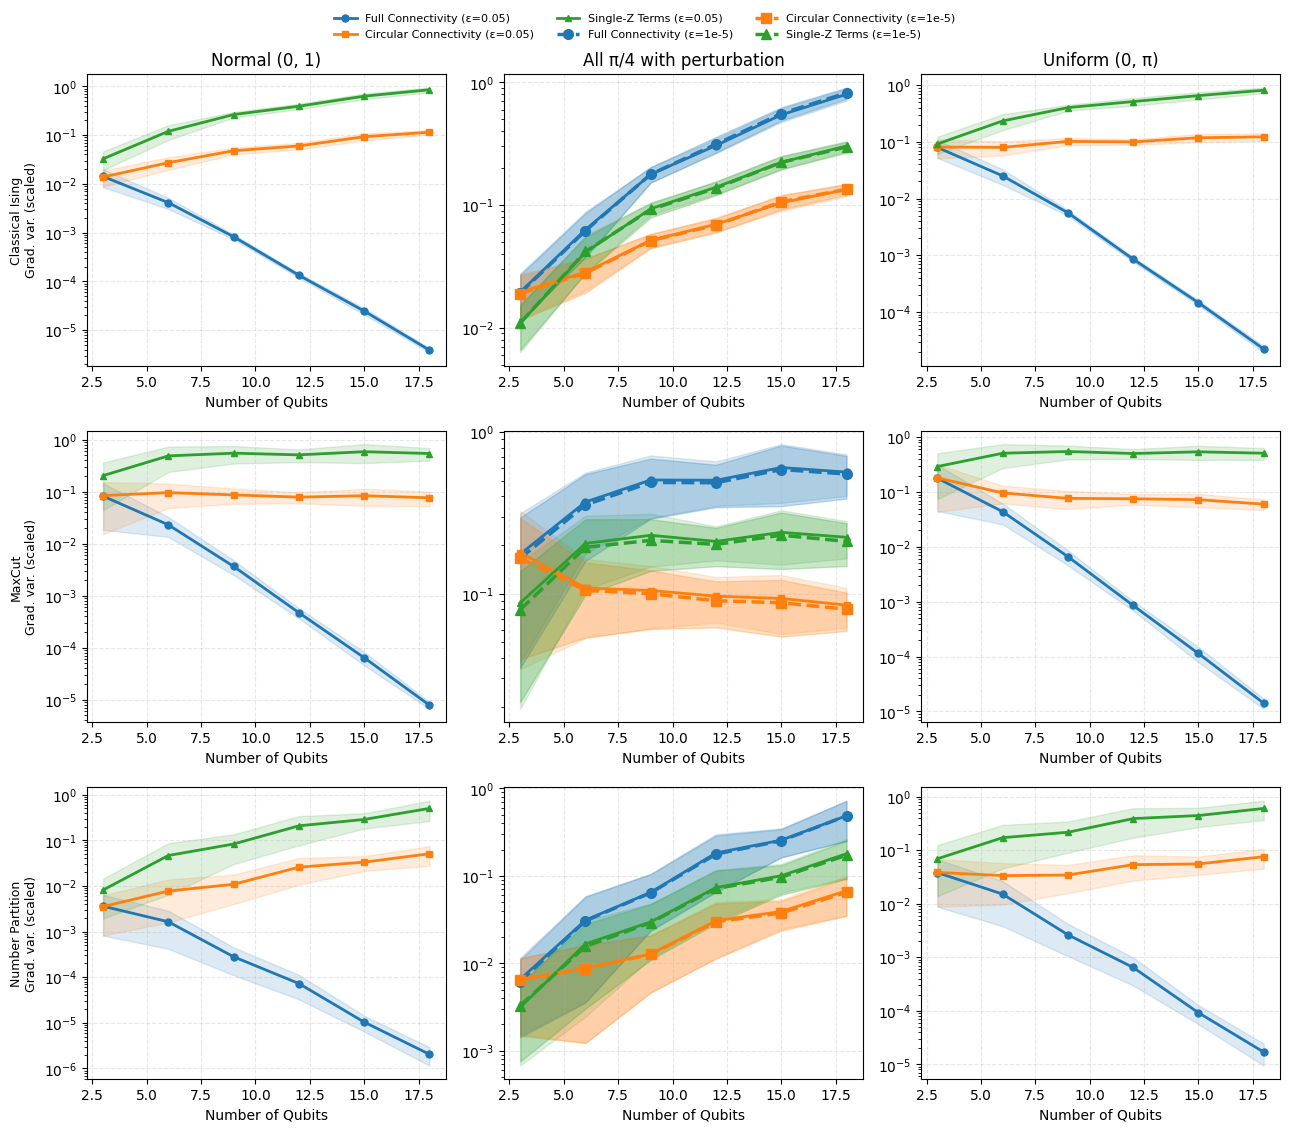

In [15]:
import json
import numpy as np
import matplotlib.pyplot as plt

with open("gv_exact_all.json", "r") as f:
    results_005 = json.load(f)

with open("gv_exact_all_eps1e-5.json", "r") as f:
    results_1e5 = json.load(f)

qubits = [3, 6, 9, 12, 15, 18]

ham_names = {
    'ising':     'Classical Ising',
    'maxcut':    'MaxCut',
    'partition': 'Number Partition'
}

# Style cho từng circuit
circuit_colors = {
    'full':     '#1f77b4',
    'circular': '#ff7f0e',
    'single':   '#2ca02c'
}
circuit_markers = {
    'full':     'o',
    'circular': 's',
    'single':   '^'
}
circuit_labels = {
    'full':     'Full Connectivity',
    'circular': 'Circular Connectivity',
    'single':   'Single-Z Terms'
}

# 3 cột: normal, pi4, uniform
init_cols = ['normal', 'pi4', 'uniform']
col_titles = {
    'normal':  'Normal (0, 1)',
    'pi4':     'All π/4 with perturbation',
    'uniform': 'Uniform (0, π)',
}

fig, axes = plt.subplots(3, 3, figsize=(13, 11))

for row, mode_ham in enumerate(['ising', 'maxcut', 'partition']):
    for col, init_name in enumerate(init_cols):
        ax = axes[row][col]

        # --- ε=0.05 luôn vẽ (nét liền) ---
        res = results_005[init_name][mode_ham]
        all_vals = [v for mc in res.values()
                      for vals in mc.values() for v in vals]
        scale = max(all_vals)

        for mode_circuit in ['full', 'circular', 'single']:
            means = np.array([np.mean(res[mode_circuit][str(n)]) / scale
                              for n in qubits])
            stds  = np.array([np.std(res[mode_circuit][str(n)]) / scale
                              for n in qubits])
            color = circuit_colors[mode_circuit]
            marker = circuit_markers[mode_circuit]
            ax.plot(qubits, means, marker + '-', color=color,
                    label=f'{circuit_labels[mode_circuit]} (ε=0.05)',
                    linewidth=2, markersize=5)
            ax.fill_between(qubits, means - stds, means + stds,
                            color=color, alpha=0.15)

        # --- ε=1e-5 chỉ vẽ ở cột pi4 (nét đứt, màu nhạt) ---
        if init_name == 'pi4':
            res2 = results_1e5[init_name][mode_ham]
            all_vals2 = [v for mc in res2.values()
                           for vals in mc.values() for v in vals]
            scale2 = max(all_vals2)

            for mode_circuit in ['full', 'circular', 'single']:
                means2 = np.array([np.mean(res2[mode_circuit][str(n)]) / scale2
                                   for n in qubits])
                stds2  = np.array([np.std(res2[mode_circuit][str(n)]) / scale2
                                   for n in qubits])
                color = circuit_colors[mode_circuit]
                marker = circuit_markers[mode_circuit]
                ax.plot(qubits, means2, marker + '--', color=color,
                        label=f'{circuit_labels[mode_circuit]} (ε=1e-5)',
                        linewidth=2.5, markersize=7,
                        alpha=1.0)          # bỏ alpha mờ
                ax.fill_between(qubits, means2 - stds2, means2 + stds2,
                                color=color, alpha=0.25)   # tăng từ 0.08 lên 0.25

        ax.set_yscale('log')
        ax.grid(True, alpha=0.3, linestyle='--')
        ax.set_xlabel('Number of Qubits')

        if col == 0:
            ax.set_ylabel(f'{ham_names[mode_ham]}\nGrad. var. (scaled)', fontsize=9)
        if row == 0:
            ax.set_title(col_titles[init_name])

# Legend: chỉ lấy từ panel pi4 hàng đầu vì có đủ cả 2 epsilon
handles, labels_ = axes[0][1].get_legend_handles_labels()
fig.legend(handles, labels_, loc='upper center', ncol=3,
           bbox_to_anchor=(0.5, 1.03), frameon=False, fontsize=8)

plt.tight_layout()
plt.savefig("GV_compare_pi4_epsilon.pdf", dpi=300, bbox_inches='tight')
plt.show()

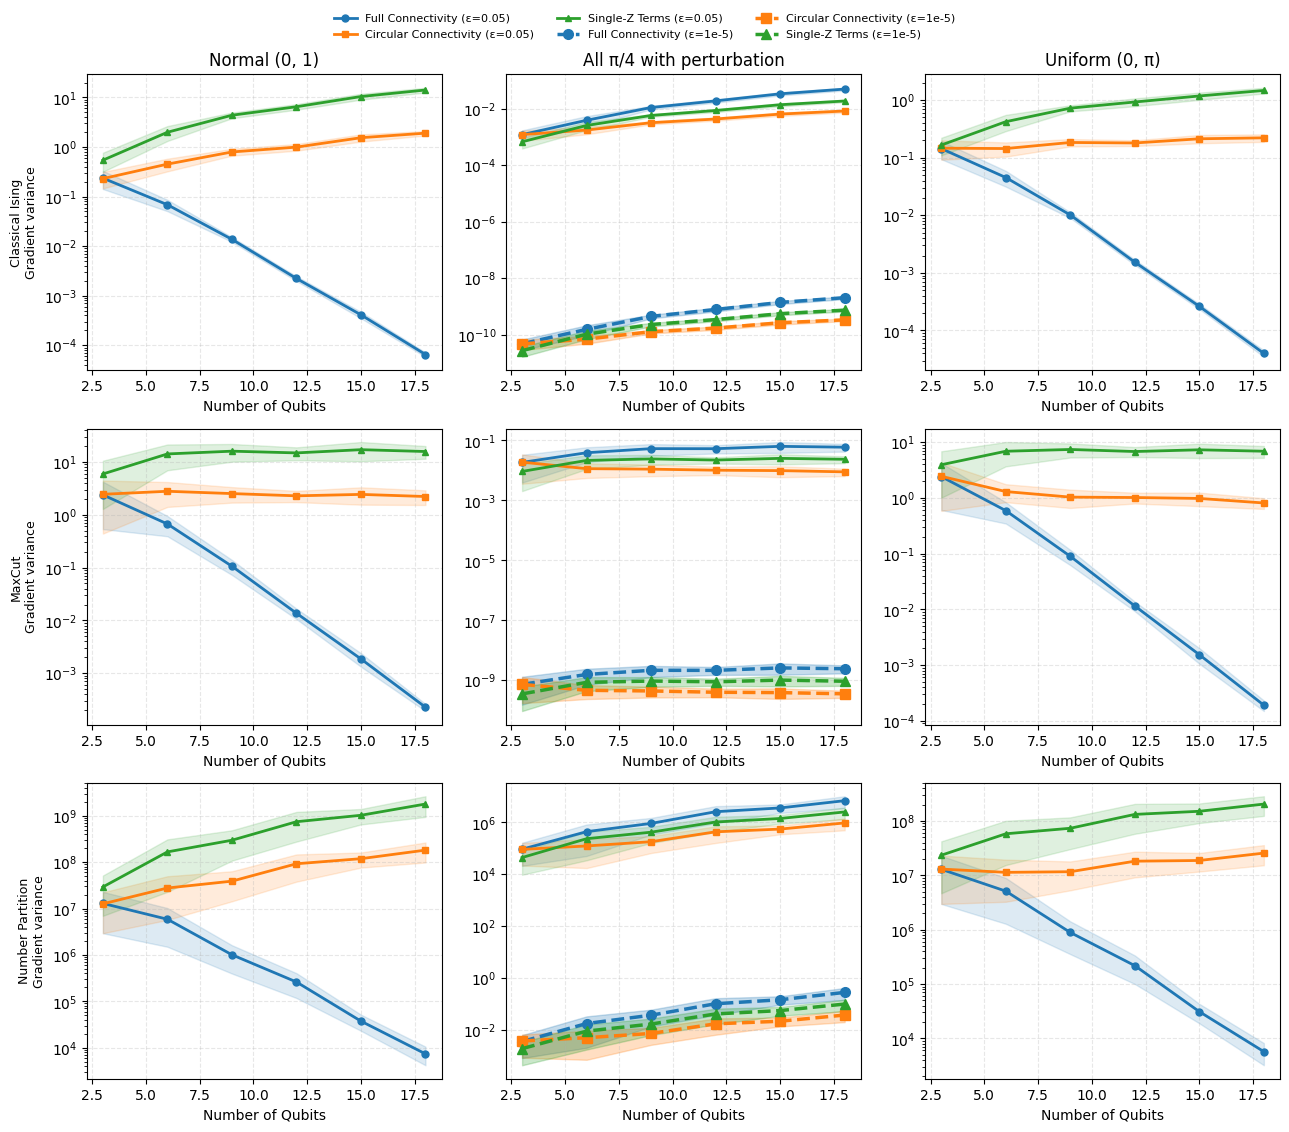

In [16]:
import json
import numpy as np
import matplotlib.pyplot as plt

with open("gv_exact_all.json", "r") as f:
    results_005 = json.load(f)

with open("gv_exact_all_eps1e-5.json", "r") as f:
    results_1e5 = json.load(f)

qubits = [3, 6, 9, 12, 15, 18]

ham_names = {
    'ising':     'Classical Ising',
    'maxcut':    'MaxCut',
    'partition': 'Number Partition'
}

# Style cho từng circuit
circuit_colors = {
    'full':     '#1f77b4',
    'circular': '#ff7f0e',
    'single':   '#2ca02c'
}
circuit_markers = {
    'full':     'o',
    'circular': 's',
    'single':   '^'
}
circuit_labels = {
    'full':     'Full Connectivity',
    'circular': 'Circular Connectivity',
    'single':   'Single-Z Terms'
}

# 3 cột: normal, pi4, uniform
init_cols = ['normal', 'pi4', 'uniform']
col_titles = {
    'normal':  'Normal (0, 1)',
    'pi4':     'All π/4 with perturbation',
    'uniform': 'Uniform (0, π)',
}

fig, axes = plt.subplots(3, 3, figsize=(13, 11))

for row, mode_ham in enumerate(['ising', 'maxcut', 'partition']):
    for col, init_name in enumerate(init_cols):
        ax = axes[row][col]

        res = results_005[init_name][mode_ham]
        for mode_circuit in ['full', 'circular', 'single']:
            means = np.array([np.mean(res[mode_circuit][str(n)]) for n in qubits])
            stds  = np.array([np.std(res[mode_circuit][str(n)])  for n in qubits])
            color = circuit_colors[mode_circuit]
            marker = circuit_markers[mode_circuit]
            ax.plot(qubits, means, marker + '-', color=color,
                    label=f'{circuit_labels[mode_circuit]} (ε=0.05)',
                    linewidth=2, markersize=5)
            ax.fill_between(qubits, means - stds, means + stds,
                            color=color, alpha=0.15)

        if init_name == 'pi4':
            res2 = results_1e5[init_name][mode_ham]
            for mode_circuit in ['full', 'circular', 'single']:
                means2 = np.array([np.mean(res2[mode_circuit][str(n)]) for n in qubits])
                stds2  = np.array([np.std(res2[mode_circuit][str(n)])  for n in qubits])
                color = circuit_colors[mode_circuit]
                marker = circuit_markers[mode_circuit]
                ax.plot(qubits, means2, marker + '--', color=color,
                        label=f'{circuit_labels[mode_circuit]} (ε=1e-5)',
                        linewidth=2.5, markersize=7, alpha=1.0)
                ax.fill_between(qubits, means2 - stds2, means2 + stds2,
                                color=color, alpha=0.25)

        ax.set_yscale('log')
        ax.grid(True, alpha=0.3, linestyle='--')
        ax.set_xlabel('Number of Qubits')
        if col == 0:
            ax.set_ylabel(f'{ham_names[mode_ham]}\nGradient variance', fontsize=9)
        if row == 0:
            ax.set_title(col_titles[init_name])

# Legend: chỉ lấy từ panel pi4 hàng đầu vì có đủ cả 2 epsilon
handles, labels_ = axes[0][1].get_legend_handles_labels()
fig.legend(handles, labels_, loc='upper center', ncol=3,
           bbox_to_anchor=(0.5, 1.03), frameon=False, fontsize=8)

plt.tight_layout()
plt.savefig("GV_compare_pi4_epsilon.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# def penn_iqp_circuit(
#     params: np.ndarray, 
#     gates: list, 
#     ops: list[np.ndarray], 
#     coeffs: np.ndarray, 
#     n_qubits: int, 
# ) -> qp.measurements.ExpectationMP:
#     """Defines the circuit that calculates the expectation value of the operator with the IQP circuit with PennyLane tools.

#     Args:
#         params (np.ndarray): The parameters of the IQP gates.
#         gates (list): The gates representation of the IQP circuit.
#         op (np.ndarray): Bitstring representation of the Z operator.
#         n_qubits (int): The total number of qubits in the circuit.

#     Returns:
#         qp.measurements.ExpectationMP: PennyLane circuit with an expectation value.
#     """
#     qp.IQP(weights = params, num_wires = n_qubits, pattern = gates)
#     obs = binary_ops_to_hamiltonian(ops, coeffs)
#     return qp.expval(obs)

# def penn_iqp_op_expval(
#     params: np.ndarray, 
#     gates: list, 
#     ops: list[np.ndarray], 
#     coeffs: np.ndarray, 
#     n_qubits: int, 
# ) -> float:
#     """Calculates the expectation value of the operator with the IQP circuit with PennyLane tools.

#     Args:
#         params (np.ndarray): The parameters of the IQP gates.
#         gates (list): The gates representation of the IQP circuit.
#         op (np.ndarray): Bitstring representation of the Z operator.
#         n_qubits (int): The total number of qubits in the circuit.

#     Returns:
#         float: Expectation value.
#     """
#     dev = qp.device("lightning.qubit", wires = n_qubits)
#     penn_iqp_circuit_exe = qp.QNode(penn_iqp_circuit, dev)
#     return penn_iqp_circuit_exe(params, gates, ops, coeffs, n_qubits)

In [6]:
def hamiltonian_data(
    data: list[np.ndarray],
    n_qubits: int,
    mode_ham: str,
    mode_circuit: str,
) -> tuple[list[np.ndarray], np.ndarray, np.ndarray]:
    """Builds the Hamiltonian representation and IQP circuit data for different problem modes.

    This function converts structured input data into:
    1. A gate pattern for an IQP circuit,
    2. A list of binary Pauli-Z observables (ops),
    3. A corresponding coefficient vector (coeffs).

    The output depends on the chosen Hamiltonian mode:
    - "ising": constructs Ising-type observables and uses provided coefficients.
    - "maxcut": converts graph edges and weights into a MaxCut Hamiltonian.
    - "partition": constructs a number partitioning Hamiltonian.

    Args:
        data (list[np.ndarray]): Input data defining the problem instance.
        n_qubits (int): Number of qubits in the system.
        mode_ham (str): Specifies the Hamiltonian type ("ising", "maxcut", "partition").
        mode_circuit (str): Specifies the IQP circuit structure used to generate gates.

    Returns:
        tuple[list[np.ndarray], np.ndarray, np.ndarray]:
            - IQP gate pattern generated from ``gens``
            - Binary observable representation (ops)
            - Coefficients associated with each observable
    """

    # Select Hamiltonian construction based on the chosen mode.
    if mode_ham == "ising":
        coeffs = np.asarray(data)
        ops = ising_obs(n_qubits, 2)

    elif mode_ham == "maxcut":
        edges, weights = data[0], data[1]
        ops, coeffs = maxcut_obs(n_qubits, edges, weights)

    elif mode_ham == "partition":
        numbers = data
        ops, coeffs = number_partition_obs(numbers)

    else:
        raise ValueError(f"Unknown mode_ham: {mode_ham}")

    # Generate IQP circuit gate pattern.
    return gens(n_qubits, mode_circuit), ops, coeffs

In [7]:
with open("ising.json", "r") as f:
    dataset_ising = json.load(f)

# Convert keys back to integers
dataset_ising = {int(k): v for k, v in dataset_ising.items()}

with open("maxcut.json", "r") as f:
    dataset_maxcut = json.load(f)

# Convert keys back to integers
dataset_maxcut = {int(k): v for k, v in dataset_maxcut.items()}

with open("partition.json", "r") as f:
    dataset_partition = json.load(f)

# Convert keys back to integers
dataset_partition = {int(k): v for k, v in dataset_partition.items()}

print("Dataset loaded successfully")

Dataset loaded successfully


In [8]:
dataset = {
    'ising': dataset_ising,
    'maxcut': dataset_maxcut,
    'partition': dataset_partition
}

In [9]:
mode_ham = 'ising'
mode_circuit = 'single'
n_qubits = 3
gates, ops, coeffs = hamiltonian_data(dataset[mode_ham][n_qubits][0], n_qubits, mode_ham, mode_circuit)

In [34]:
params = qnp.random.rand(len(gates), requires_grad=True)
cost(params, n_qubits, gates, ops, coeffs)

tensor(1.31762107, requires_grad=True)

In [37]:
# opt = qp.AdamOptimizer(stepsize=0.05)

# params = qnp.array(params, requires_grad=True)

# for i in range(200):
#     params = opt.step(
#         lambda p: cost(p, n_qubits, gates, ops, coeffs),
#         params
#     )

#     if i % 10 == 0:
#         print(i, cost(params, n_qubits, gates, ops, coeffs))

ValueError: setting an array element with a sequence.

In [3]:
import pennylane as qml
import pennylane.numpy as np

# 1. Set up the device
dev = qml.device("default.qubit", wires=2)

# 2. Define the IQP circuit using QNode
@qml.qnode(dev, diff_method="parameter-shift")
def iqp_circuit(weights, pattern, spin_sym):
    # Apply the built-in IQP template
    qml.IQP(weights=weights, num_wires=2, pattern=pattern, spin_sym=spin_sym)
    return qml.expval(qml.PauliZ(0))

# Initialize parameters as trainable arrays
weights = np.array([0.89, 0.54], requires_grad=True)
pattern = [[[0]], [[1]]]
spin_sym = False

# 3. Calculate the gradient
grad_fn = qml.grad(iqp_circuit)
gradients = grad_fn(weights, pattern, spin_sym)

print("Weights:", weights)
print("Gradients:", gradients)

ValueError: setting an array element with a sequence.

In [ ]:
dev = qp.device("default.qubit")

@qp.qnode(dev, interface="autograd")
def circuit(params, n_qubits, gates, ops, coeffs):
    qp.IQP(weights = params, num_wires = n_qubits, pattern = gates)
    obs = binary_ops_to_hamiltonian(ops, coeffs)
    return qp.expval(obs)

def cost(params, n_qubits, gates, ops, coeffs):
    return qnp.array(circuit(params, n_qubits, gates, ops, coeffs))

In [ ]:
n_qubits = 30
gates = []
for i in range(n_qubits):
    gates.append([[i]])
for i in range(n_qubits):
    for j in range(i+1, n_qubits):
        gates.append([[i, j]])

In [ ]:
gates = [[[0]], [[1]], [[2]], [[0,1]], [[0,2]], [[1,2]]]
n_qubits = 3
op = np.array([1,0,1]) # operator ZIZ
params = np.random.rand(len(gates)) # random parameters for all the gates (remember we have 5 gates with 6 generators in total)

penn_op_expval = penn_iqp_op_expval(params, gates, op, n_qubits)
print("Expectation value: ", penn_op_expval)